# Telco Customer Churn — Statistical Hypothesis Testing & EDA
### AIML Project | 





In [53]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RESULTS = [] 
ALPHA = 0.05  
print("Setup complete.")


Setup complete.


## 2. Data loading and cleaning



In [54]:
# NOTE: the original absolute Windows path has been swapped for a relative one so this
# notebook runs anywhere the paired data file is kept alongside it.
raw = pd.read_excel("Telco_Customer_Churn_Merged.xlsx")
print("Raw shape:", raw.shape)

df = pd.DataFrame()
df["customerID"] = raw["Customer ID"]
df["gender"] = raw["Gender"]
df["SeniorCitizen"] = raw["Senior Citizen_x"]
df["Partner"] = raw["Partner"]
df["Dependents"] = raw["Dependents_x"]
df["tenure"] = raw["Tenure"]
df["PhoneService"] = raw["Phone Service_x"]
df["MultipleLines"] = raw["Multiple Lines_x"]
df["InternetService"] = raw["Internet Service_x"]
df["OnlineSecurity"] = raw["Online Security_x"]
df["OnlineBackup"] = raw["Online Backup_x"]
df["DeviceProtection"] = raw["Device Protection"]
df["TechSupport"] = raw["Tech Support"]
df["StreamingTV"] = raw["Streaming TV_x"]
df["StreamingMovies"] = raw["Streaming Movies_x"]
df["Contract"] = raw["Contract_x"]
df["PaperlessBilling"] = raw["Paperless Billing_x"]
df["PaymentMethod"] = raw["Payment Method_x"]
df["MonthlyCharges"] = raw["Monthly Charges"]
df["TotalCharges"] = raw["Total Charges_x"]
df["Churn"] = raw["Churn"]

# extra fields from the IBM extended half
df["Age"] = raw["Age"]
df["SatisfactionScore"] = raw["Satisfaction Score"]
df["CLTV"] = raw["CLTV"]
df["NumReferrals"] = raw["Number of Referrals"]

df.head()


Raw shape: (7043, 25)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Age,SatisfactionScore,CLTV,NumReferrals
0,6857-SIVUG,Female,0,Yes,Yes,50,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Credit card (automatic),101.46,5045.35,Yes,23,3,4441,1
1,6016-LKSKE,Male,1,Yes,No,34,Yes,No,No,No internet service,...,Month-to-month,No,Mailed check,26.77,911.54,No,65,3,4093,1
2,9474-KZFID,Female,1,No,Yes,18,Yes,Yes,Fiber optic,No,...,Two year,Yes,Bank transfer (automatic),102.32,1880.83,No,84,3,4311,0
3,1410-XJQDP,Female,0,Yes,Yes,20,Yes,Yes,DSL,No,...,Two year,Yes,Credit card (automatic),64.29,1273.77,No,27,4,3538,3
4,8848-LFPLN,Male,0,No,No,25,Yes,No,DSL,No,...,Two year,No,Electronic check,73.01,1821.67,No,29,2,4391,0


In [55]:
# Quirk 1: TotalCharges blank strings -> numeric, fill with 0 for brand-new customers
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_blank = df["TotalCharges"].isna().sum()
all_new = (df.loc[df["TotalCharges"].isna(), "tenure"] == 0).all()
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"Coerced {n_blank} blank TotalCharges strings -> 0 "
      f"(all of them are tenure==0 new customers: {all_new})")

# Quirk 2: collapse "No internet/phone service" pseudo-categories into "No"
collapse_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
                  "StreamingTV", "StreamingMovies"]
for c in collapse_cols:
    df[c] = df[c].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                              labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])

print("\nCleaned shape:", df.shape)
print("Missing values remaining:", df.isna().sum().sum())
print("Overall churn rate: {:.2%}  (class imbalance ~26.6%% as documented)".format(df["ChurnFlag"].mean()))


Coerced 8 blank TotalCharges strings -> 0 (all of them are tenure==0 new customers: True)

Cleaned shape: (7043, 27)
Missing values remaining: 0
Overall churn rate: 27.87%  (class imbalance ~26.6%% as documented)


## 3. Exploratory data analysis


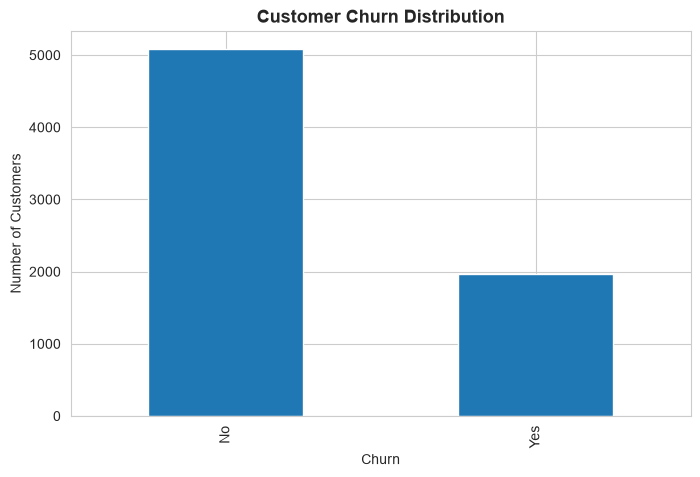

In [6]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

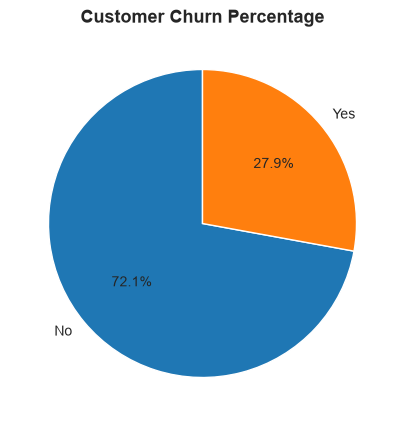

In [7]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9988\3322705392.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 0], palette=["#2E86AB", "#E63946"])


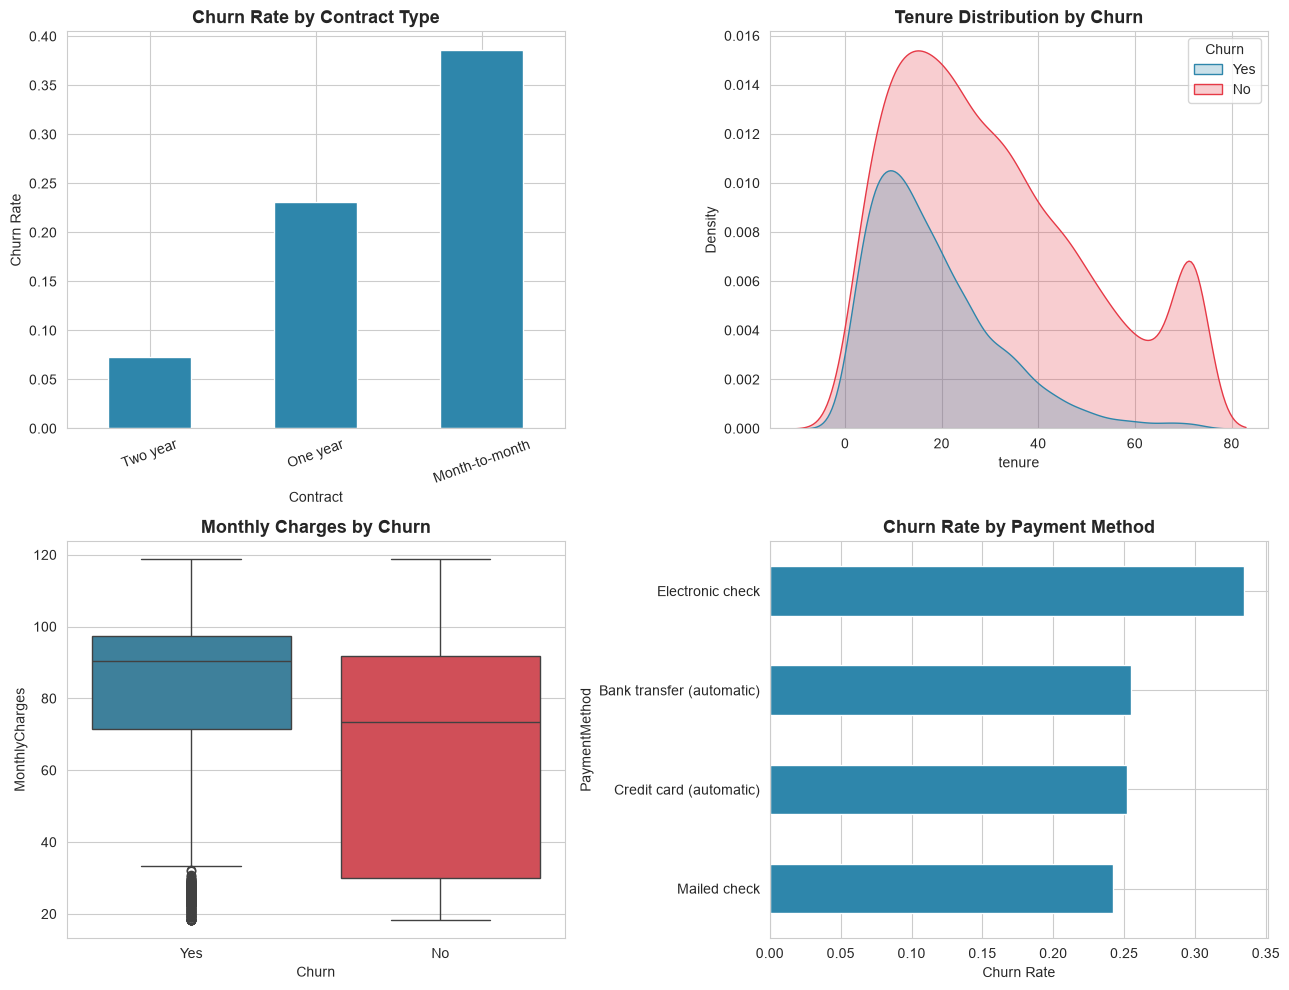

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ct = df.groupby("Contract")["ChurnFlag"].mean().sort_values()
ct.plot(kind="bar", ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Churn Rate by Contract Type")
axes[0, 0].set_ylabel("Churn Rate")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, ax=axes[0, 1], palette=["#2E86AB", "#E63946"])
axes[0, 1].set_title("Tenure Distribution by Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 0], palette=["#2E86AB", "#E63946"])
axes[1, 0].set_title("Monthly Charges by Churn")

pm = df.groupby("PaymentMethod")["ChurnFlag"].mean().sort_values()
pm.plot(kind="barh", ax=axes[1, 1], color="#2E86AB")
axes[1, 1].set_title("Churn Rate by Payment Method")
axes[1, 1].set_xlabel("Churn Rate")

plt.tight_layout()
plt.show()


## 4. Hypothesis-testing framework

Three kinds of comparisons come up repeatedly, so we wrap each in a reusable helper:

| Comparison | Test | Effect size |
|---|---|---|
| categorical vs. categorical (e.g. Contract vs. Churn) | Chi-square test of independence | Cramér's V |
| numeric vs. binary group (e.g. tenure vs. Churn) | Welch's t-test (if both groups ~normal) else Mann-Whitney U | Cohen's d / rank-biserial r |
| numeric vs. 3+ groups (e.g. TotalCharges vs. Contract) | One-way ANOVA | — |




In [9]:
def cramers_v(chi2, n, r, c):
    """Effect size for chi-square test of independence (0=no association, 1=perfect)."""
    return np.sqrt((chi2 / n) / (min(r - 1, c - 1)))


def cohend(a, b):
    """Cohen's d for two independent samples."""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std


def chi_square_test(col, hypothesis):
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, exp = stats.chi2_contingency(table)
    v = cramers_v(chi2, table.values.sum(), *table.shape)
    decision = "REJECT H0" if p < ALPHA else "FAIL TO REJECT H0"
    RESULTS.append({"Hypothesis": hypothesis, "Test": "Chi-square test of independence",
                     "Statistic": f"chi2={chi2:.2f}, dof={dof}", "p-value": p,
                     "Effect size": f"Cramer's V={v:.3f}", "Decision": decision})
    print(f"[{col}] chi2={chi2:.2f}, dof={dof}, p={p:.4g}, Cramer's V={v:.3f} -> {decision}")
    return table, p


def two_group_test(numeric_col, hypothesis, group_col="Churn", groups=("Yes", "No")):
    a = df.loc[df[group_col] == groups[0], numeric_col].dropna()
    b = df.loc[df[group_col] == groups[1], numeric_col].dropna()
    _, p_norm_a = stats.shapiro(a.sample(min(500, len(a)), random_state=1))
    _, p_norm_b = stats.shapiro(b.sample(min(500, len(b)), random_state=1))
    normal = (p_norm_a > 0.05) and (p_norm_b > 0.05)
    if normal:
        stat, p = stats.ttest_ind(a, b, equal_var=False)
        test_name, effect = "Welch's t-test", f"Cohen's d={cohend(a, b):.3f}"
    else:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        r = 1 - (2 * stat) / (len(a) * len(b))
        test_name, effect = "Mann-Whitney U (non-normal)", f"rank-biserial r={r:.3f}"
    decision = "REJECT H0" if p < ALPHA else "FAIL TO REJECT H0"
    RESULTS.append({"Hypothesis": hypothesis, "Test": test_name, "Statistic": f"stat={stat:.2f}",
                     "p-value": p, "Effect size": effect, "Decision": decision})
    print(f"[{numeric_col}] {test_name}: stat={stat:.2f}, p={p:.4g}, {effect} -> {decision}")
    print(f"   Churn=Yes mean={a.mean():.2f} (n={len(a)}) | Churn=No mean={b.mean():.2f} (n={len(b)})")
    return p


def anova_test(numeric_col, group_col, hypothesis):
    groups = [g[numeric_col].dropna().values for _, g in df.groupby(group_col)]
    stat, p = stats.f_oneway(*groups)
    decision = "REJECT H0" if p < ALPHA else "FAIL TO REJECT H0"
    RESULTS.append({"Hypothesis": hypothesis, "Test": "One-way ANOVA", "Statistic": f"F={stat:.2f}",
                     "p-value": p, "Effect size": "-", "Decision": decision})
    print(f"[{numeric_col} by {group_col}] ANOVA F={stat:.2f}, p={p:.4g} -> {decision}")
    return p

print("Helper functions defined.")


Helper functions defined.


## 5. The ten hypothesis tests


### H1 — Contract type is associated with churn
**H0:** Contract type and churn are independent. **H1:** They are associated.

In [10]:
chi_square_test("Contract", "H1: Contract type is associated with churn");

[Contract] chi2=592.60, dof=2, p=2.083e-129, Cramer's V=0.290 -> REJECT H0


### H2 — Tenure differs between churners and non-churners
**H0:** The distribution of tenure is the same for churners and non-churners. **H1:** It differs.

In [11]:
two_group_test("tenure", "H2: Tenure differs between churners and non-churners");

[tenure] Mann-Whitney U (non-normal): stat=3078953.50, p=3.339e-137, rank-biserial r=0.382 -> REJECT H0
   Churn=Yes mean=18.16 (n=1963) | Churn=No mean=30.80 (n=5080)


### H3 — Monthly charges differ between churners and non-churners
**H0:** The distribution of MonthlyCharges is the same for churners and non-churners. **H1:** It differs.

In [12]:
two_group_test("MonthlyCharges", "H3: Monthly charges differ between churners and non-churners");

[MonthlyCharges] Mann-Whitney U (non-normal): stat=6480879.50, p=5.176e-85, rank-biserial r=-0.300 -> REJECT H0
   Churn=Yes mean=81.78 (n=1963) | Churn=No mean=67.77 (n=5080)


### H4 — Payment method is associated with churn
**H0:** Payment method and churn are independent. **H1:** They are associated (electronic check is
flagged in the project brief as a suspected driver).

In [13]:
chi_square_test("PaymentMethod", "H4: Payment method is associated with churn");

[PaymentMethod] chi2=57.79, dof=3, p=1.739e-12, Cramer's V=0.091 -> REJECT H0


### H5 — Internet service type is associated with churn
**H0:** Internet service type and churn are independent. **H1:** They are associated.

In [14]:
chi_square_test("InternetService", "H5: Internet service type is associated with churn");

[InternetService] chi2=434.14, dof=2, p=5.339e-95, Cramer's V=0.248 -> REJECT H0


### H6 — Senior citizen status is associated with churn
**H0:** SeniorCitizen and churn are independent. **H1:** They are associated.

In [15]:
chi_square_test("SeniorCitizen", "H6: Senior citizen status is associated with churn");

[SeniorCitizen] chi2=4.53, dof=1, p=0.03333, Cramer's V=0.025 -> REJECT H0


### H7 — Tech support subscription is associated with churn
**H0:** TechSupport and churn are independent. **H1:** They are associated.

In [16]:
chi_square_test("TechSupport", "H7: Tech support subscription is associated with churn");

[TechSupport] chi2=0.64, dof=1, p=0.4221, Cramer's V=0.010 -> FAIL TO REJECT H0


### H8 — Online security subscription is associated with churn
**H0:** OnlineSecurity and churn are independent. **H1:** They are associated.

In [17]:
chi_square_test("OnlineSecurity", "H8: Online security subscription is associated with churn");

[OnlineSecurity] chi2=2.19, dof=1, p=0.1393, Cramer's V=0.018 -> FAIL TO REJECT H0


### H9 — Total charges differ across contract types
**H0:** Mean TotalCharges is equal across Month-to-month / One year / Two year contracts.
**H1:** At least one group mean differs.

In [18]:
anova_test("TotalCharges", "Contract", "H9: Total charges differ across contract types");

[TotalCharges by Contract] ANOVA F=1.86, p=0.1555 -> FAIL TO REJECT H0


### H10 — Satisfaction score differs between churners and non-churners
**H0:** The distribution of SatisfactionScore is the same for churners and non-churners. **H1:** It differs.

In [19]:
two_group_test("SatisfactionScore", "H10: Satisfaction score differs between churners and non-churners");

[SatisfactionScore] Mann-Whitney U (non-normal): stat=2262422.00, p=5.994e-304, rank-biserial r=0.546 -> REJECT H0
   Churn=Yes mean=1.87 (n=1963) | Churn=No mean=2.82 (n=5080)


## 6. Multiple-testing correction & summary table

Running 10 tests at &alpha; = 0.05 inflates the family-wise false-positive rate. A **Bonferroni
correction** (&alpha;/10 = 0.005) is applied as a conservative check on which results survive multiple
comparisons.

In [20]:
results_df = pd.DataFrame(RESULTS)
m = len(results_df)
bonf_alpha = ALPHA / m
results_df["Bonferroni alpha"] = bonf_alpha
results_df["Significant (Bonferroni)"] = results_df["p-value"] < bonf_alpha
results_df_display = results_df.copy()
results_df_display["p-value"] = results_df_display["p-value"].apply(lambda p: f"{p:.4g}")

print(f"{m} hypothesis tests run | family-wise Bonferroni alpha = {bonf_alpha:.5f}")
results_df_display


10 hypothesis tests run | family-wise Bonferroni alpha = 0.00500


,Hypothesis,Test,Statistic,p-value,Effect size,Decision,Bonferroni alpha,Significant (Bonferroni)
0,H1: Contract type is associated with churn,Chi-square test of independence,"chi2=592.60, dof=2",2.083e-129,Cramer's V=0.290,REJECT H0,0.005,True
1,H2: Tenure differs between churners and non-ch...,Mann-Whitney U (non-normal),stat=3078953.50,3.339e-137,rank-biserial r=0.382,REJECT H0,0.005,True
2,H3: Monthly charges differ between churners an...,Mann-Whitney U (non-normal),stat=6480879.50,5.176e-85,rank-biserial r=-0.300,REJECT H0,0.005,True
3,H4: Payment method is associated with churn,Chi-square test of independence,"chi2=57.79, dof=3",1.739e-12,Cramer's V=0.091,REJECT H0,0.005,True
4,H5: Internet service type is associated with c...,Chi-square test of independence,"chi2=434.14, dof=2",5.339e-95,Cramer's V=0.248,REJECT H0,0.005,True
5,H6: Senior citizen status is associated with c...,Chi-square test of independence,"chi2=4.53, dof=1",0.03333,Cramer's V=0.025,REJECT H0,0.005,False
6,H7: Tech support subscription is associated wi...,Chi-square test of independence,"chi2=0.64, dof=1",0.4221,Cramer's V=0.010,FAIL TO REJECT H0,0.005,False
7,H8: Online security subscription is associated...,Chi-square test of independence,"chi2=2.19, dof=1",0.1393,Cramer's V=0.018,FAIL TO REJECT H0,0.005,False
8,H9: Total charges differ across contract types,One-way ANOVA,F=1.86,0.1555,-,FAIL TO REJECT H0,0.005,False
9,H10: Satisfaction score differs between churne...,Mann-Whitney U (non-normal),stat=2262422.00,5.994e-304,rank-biserial r=0.546,REJECT H0,0.005,True


## 7. Correlation analysis

Point-biserial correlation (a Pearson correlation where one variable is binary) between churn and the
key numeric features, plus a full correlation heatmap for context.

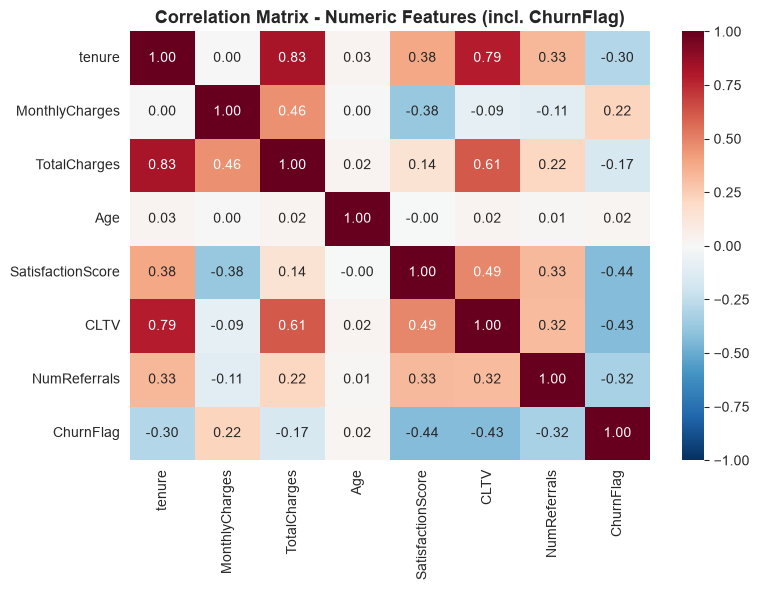


Point-biserial correlations with churn:
  tenure               r=-0.296  p=5.991e-142
  MonthlyCharges       r=+0.224  p=1.118e-80
  TotalCharges         r=-0.168  p=6.053e-46
  SatisfactionScore    r=-0.436  p=0
  CLTV                 r=-0.431  p=4.059e-317


In [21]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Age", "SatisfactionScore", "CLTV",
            "NumReferrals", "ChurnFlag"]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numeric Features (incl. ChurnFlag)")
plt.tight_layout()
plt.show()

print("\nPoint-biserial correlations with churn:")
for c in ["tenure", "MonthlyCharges", "TotalCharges", "SatisfactionScore", "CLTV"]:
    r, p = stats.pointbiserialr(df["ChurnFlag"], df[c])
    print(f"  {c:20s} r={r:+.3f}  p={p:.4g}")


In [22]:
print(df.select_dtypes(include="object").columns.tolist())

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\3652556950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [23]:
df.drop("customerID", axis=1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Age,SatisfactionScore,CLTV,NumReferrals,ChurnFlag,tenure_bucket
0,Female,0,Yes,Yes,50,Yes,No,Fiber optic,No,Yes,...,Credit card (automatic),101.46,5045.35,Yes,23,3,4441,1,1,49-72 mo
1,Male,1,Yes,No,34,Yes,No,No,No,No,...,Mailed check,26.77,911.54,No,65,3,4093,1,0,25-48 mo
2,Female,1,No,Yes,18,Yes,Yes,Fiber optic,No,Yes,...,Bank transfer (automatic),102.32,1880.83,No,84,3,4311,0,0,13-24 mo
3,Female,0,Yes,Yes,20,Yes,Yes,DSL,No,Yes,...,Credit card (automatic),64.29,1273.77,No,27,4,3538,3,0,13-24 mo
4,Male,0,No,No,25,Yes,No,DSL,No,Yes,...,Electronic check,73.01,1821.67,No,29,2,4391,0,0,25-48 mo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,No,No,28,Yes,No,DSL,No,No,...,Bank transfer (automatic),74.43,2079.03,No,59,2,4645,1,0,25-48 mo
7039,Female,0,No,No,22,Yes,Yes,DSL,Yes,Yes,...,Electronic check,73.72,1641.13,Yes,64,3,3814,0,1,13-24 mo
7040,Female,0,No,No,22,Yes,No,Fiber optic,No,No,...,Electronic check,82.18,1794.36,No,47,3,4103,0,0,13-24 mo
7041,Male,0,No,Yes,20,Yes,Yes,Fiber optic,No,Yes,...,Bank transfer (automatic),94.81,1954.16,Yes,50,2,3722,0,1,13-24 mo


In [24]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", df[col].nunique())

customerID : 7043
gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 2
InternetService : 3
OnlineSecurity : 2
OnlineBackup : 2
DeviceProtection : 2
TechSupport : 2
StreamingTV : 2
StreamingMovies : 2
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
Churn : 2


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\4039122010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [25]:
df.drop(columns=["customerID"], inplace=True)

In [26]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Age', 'SatisfactionScore', 'CLTV', 'NumReferrals', 'ChurnFlag', 'tenure_bucket']


In [27]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\694774301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = []

for col in df.select_dtypes(include="object").columns:
    if df[col].nunique() == 2:
        binary_cols.append(col)
        df[col] = le.fit_transform(df[col])

print("Binary Encoded Columns:")
print(binary_cols)

Binary Encoded Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\2235510632.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [29]:
multi_cols = []

for col in df.select_dtypes(include="object").columns:
    if df[col].nunique() > 2:
        multi_cols.append(col)

print("One-Hot Encoded Columns:")
print(multi_cols)

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

One-Hot Encoded Columns:
['InternetService', 'Contract', 'PaymentMethod']


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\2006134130.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [30]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,NumReferrals,ChurnFlag,tenure_bucket,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,50,1,0,0,1,0,...,1,1,49-72 mo,True,False,False,False,True,False,False
1,1,1,1,0,34,1,0,0,0,0,...,1,0,25-48 mo,False,True,False,False,False,False,True
2,0,1,0,1,18,1,1,0,1,0,...,0,0,13-24 mo,True,False,False,True,False,False,False
3,0,0,1,1,20,1,1,0,1,0,...,3,0,13-24 mo,False,False,False,True,True,False,False
4,1,0,0,0,25,1,0,0,1,0,...,0,0,25-48 mo,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,28,1,0,0,0,0,...,1,0,25-48 mo,False,False,False,False,False,False,False
7039,0,0,0,0,22,1,1,1,1,0,...,0,1,13-24 mo,False,False,True,False,False,True,False
7040,0,0,0,0,22,1,0,0,0,0,...,0,0,13-24 mo,True,False,False,True,False,True,False
7041,1,0,0,1,20,1,1,0,1,0,...,0,1,13-24 mo,True,False,False,False,False,False,False


In [31]:
df.shape

(7043, 30)

In [32]:
X = df.drop(columns=["ChurnFlag", "Churn"])
y = df["ChurnFlag"]

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("Object columns:", X.select_dtypes(include="object").columns.tolist())

X shape: (7043, 30)
Object columns: []


In [33]:
print(X.select_dtypes(include="object").columns.tolist())

[]


# Train/Test split 

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "| Churn rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape,  "| Churn rate:", y_test.mean().round(4))

Train shape: (5634, 30) | Churn rate: 0.2787
Test shape:  (1409, 30) | Churn rate: 0.2789


# Baseline Models
### format of output

In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

MODEL_RESULTS = []

def evaluate(name, model, X_te, y_te, y_pred, y_proba=None):
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_te, y_proba)
    MODEL_RESULTS.append(metrics)

    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=["No Churn", "Churn"]))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
    return metrics

# Logistic  Regression

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.87      0.89      0.88      1016
       Churn       0.69      0.65      0.67       393

    accuracy                           0.82      1409
   macro avg       0.78      0.77      0.77      1409
weighted avg       0.82      0.82      0.82      1409



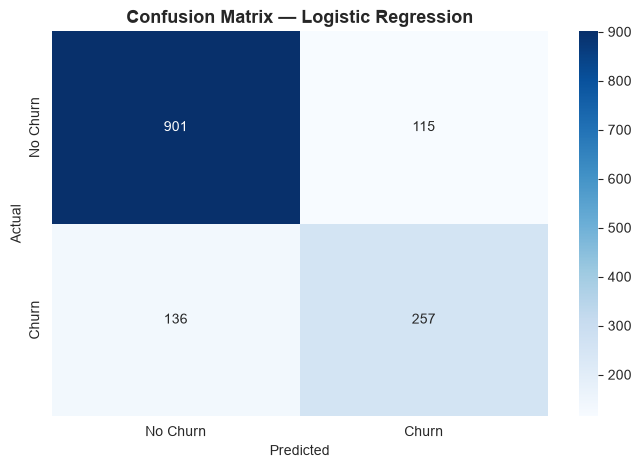

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

evaluate("Logistic Regression", logreg, X_test_scaled, y_test, y_pred_lr, y_proba_lr);

# Decision tree 

--- Decision Tree (depth=5) ---
              precision    recall  f1-score   support

    No Churn       0.82      0.91      0.86      1016
       Churn       0.68      0.50      0.58       393

    accuracy                           0.79      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



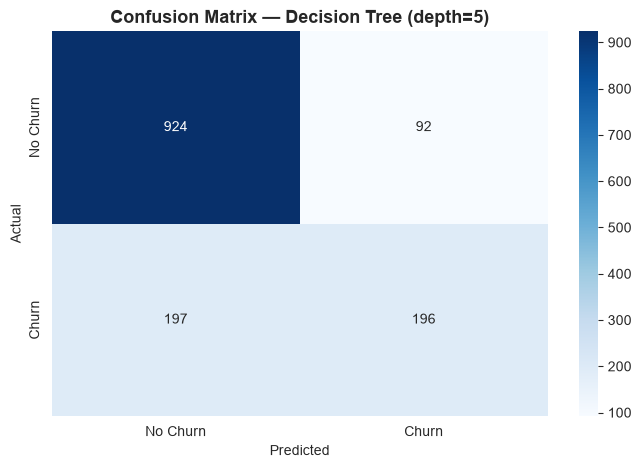

In [37]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)   # trees don't need scaling

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

evaluate("Decision Tree (depth=5)", tree, X_test, y_test, y_pred_tree, y_proba_tree);

In [38]:
results_summary = pd.DataFrame(MODEL_RESULTS).set_index("Model").round(4)
results_summary

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8219,0.6909,0.6539,0.6719,0.8731
Decision Tree (depth=5),0.7949,0.6806,0.4987,0.5756,0.8360


--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1016
       Churn       0.61      0.58      0.59       393

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.77      0.78      0.78      1409



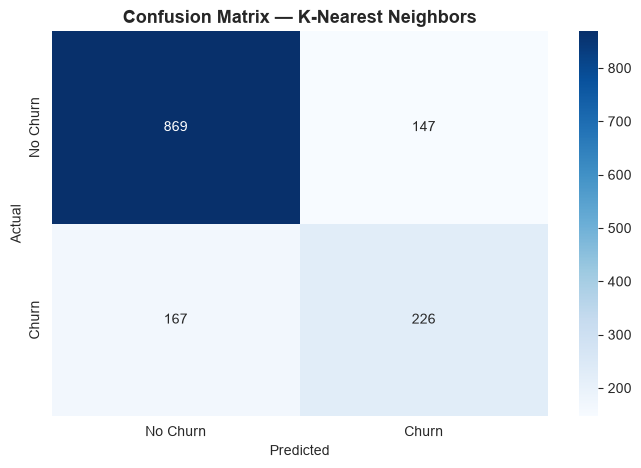

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)   # reuse the scaler fit earlier on X_train

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

evaluate("K-Nearest Neighbors", knn, X_test_scaled, y_test, y_pred_knn, y_proba_knn);

--- Gradient Boosting ---
              precision    recall  f1-score   support

    No Churn       0.86      0.88      0.87      1016
       Churn       0.68      0.62      0.65       393

    accuracy                           0.81      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.81      0.81      1409



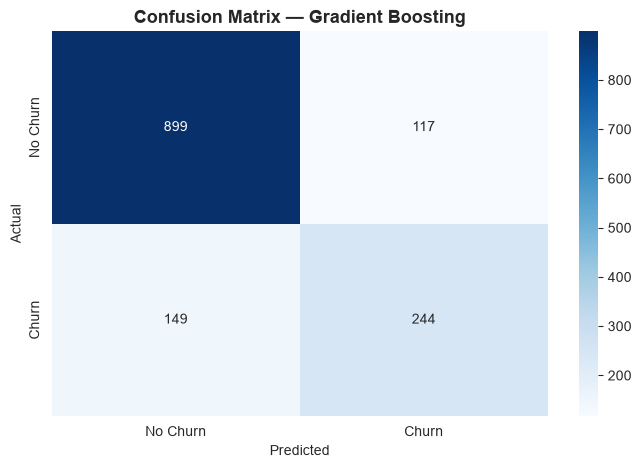

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

evaluate("Gradient Boosting", gb, X_test, y_test, y_pred_gb, y_proba_gb);

# XGBoost (gradient-boosted trees, separate library)

--- XGBoost ---
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1016
       Churn       0.56      0.80      0.66       393

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



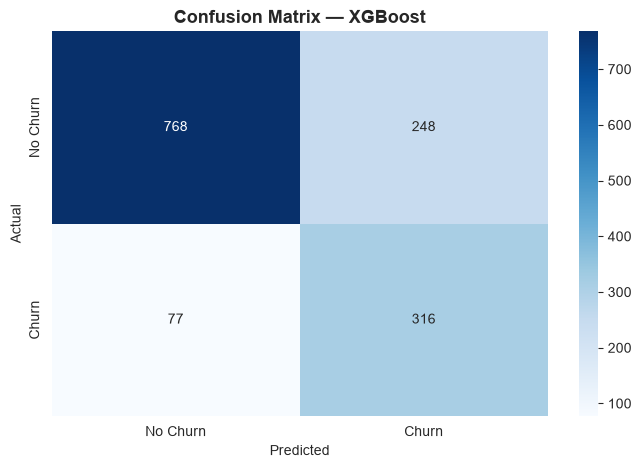

In [41]:
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "-q"], check=True)
    from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

evaluate("XGBoost", xgb, X_test, y_test, y_pred_xgb, y_proba_xgb);

#  Random Forest 

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1016
       Churn       0.57      0.82      0.67       393

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



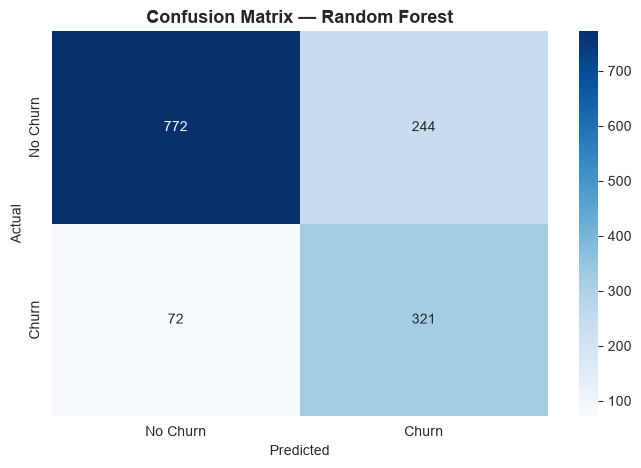

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)   # tree-based, no scaling needed

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

evaluate("Random Forest", rf, X_test, y_test, y_pred_rf, y_proba_rf);

#  Support Vector Machine

C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- Support Vector Machine ---
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1016
       Churn       0.55      0.81      0.65       393

    accuracy                           0.76      1409
   macro avg       0.73      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



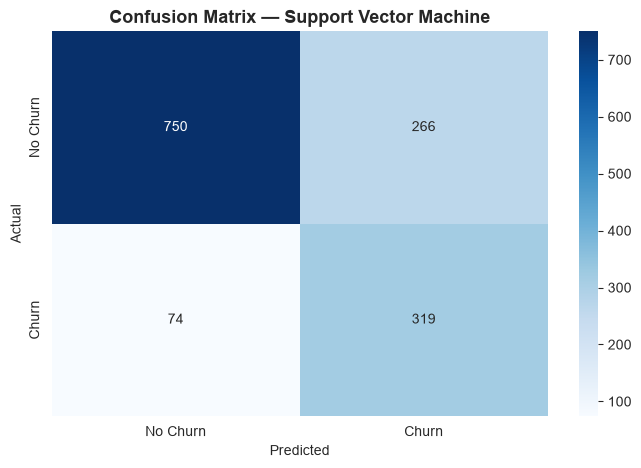

In [43]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train_scaled, y_train)   # SVM needs scaled features too

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

evaluate("Support Vector Machine", svm, X_test_scaled, y_test, y_pred_svm, y_proba_svm);

In [44]:
results_summary_full = pd.DataFrame(MODEL_RESULTS).set_index("Model").round(4)
results_summary_full = results_summary_full.sort_values("ROC-AUC", ascending=False)
results_summary_full

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8219,0.6909,0.6539,0.6719,0.8731
Gradient Boosting,0.8112,0.6759,0.6209,0.6472,0.8671
Random Forest,0.7757,0.5681,0.8168,0.6701,0.8652
XGBoost,0.7693,0.5603,0.8041,0.6604,0.8615
Support Vector Machine,0.7587,0.5453,0.8117,0.6524,0.8574
Decision Tree (depth=5),0.7949,0.6806,0.4987,0.5756,0.8360
K-Nearest Neighbors,0.7771,0.6059,0.5751,0.5901,0.8113


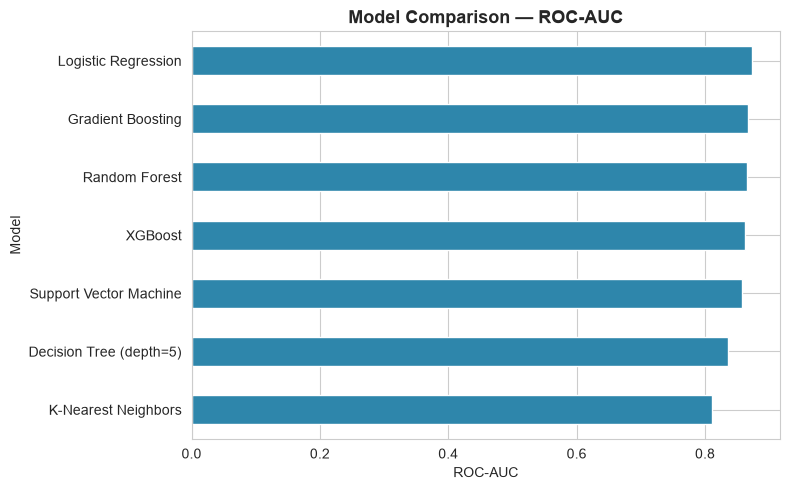

In [45]:
results_summary_full["ROC-AUC"].sort_values().plot(kind="barh", color="#2E86AB", figsize=(8,5))
plt.title("Model Comparison — ROC-AUC")
plt.xlabel("ROC-AUC")
plt.tight_layout()
plt.show()

# ROC curve comparison

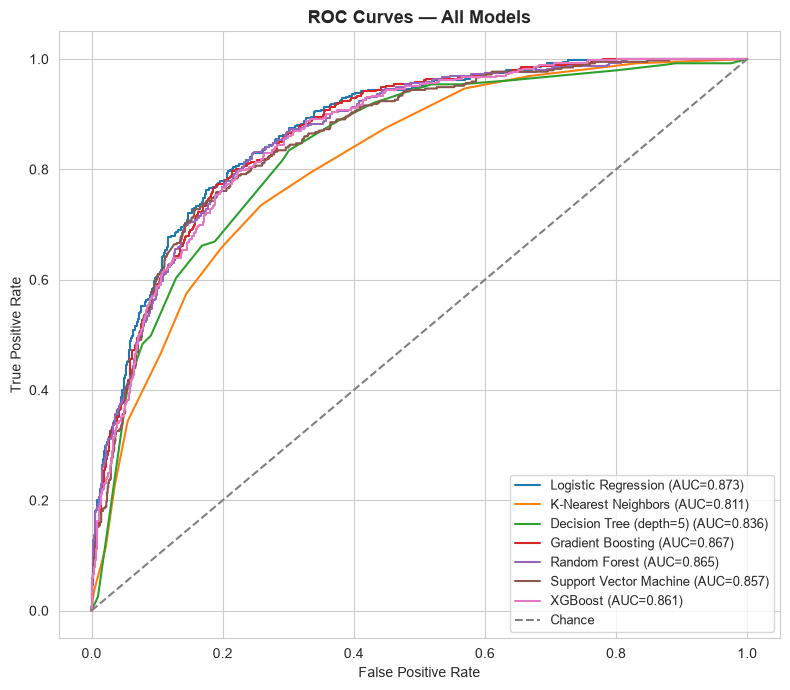

In [46]:
from sklearn.metrics import roc_curve

roc_inputs = {
    "Logistic Regression": (y_test, y_proba_lr),
    "K-Nearest Neighbors": (y_test, y_proba_knn),
    "Decision Tree (depth=5)": (y_test, y_proba_tree),
    "Gradient Boosting": (y_test, y_proba_gb),
    "Random Forest": (y_test, y_proba_rf),
    "Support Vector Machine": (y_test, y_proba_svm),
    "XGBoost": (y_test, y_proba_xgb),
}

plt.figure(figsize=(8, 7))
for name, (y_true, y_proba) in roc_inputs.items():
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.title("ROC Curves — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# Feature importance (Random Forest & XGBoost)

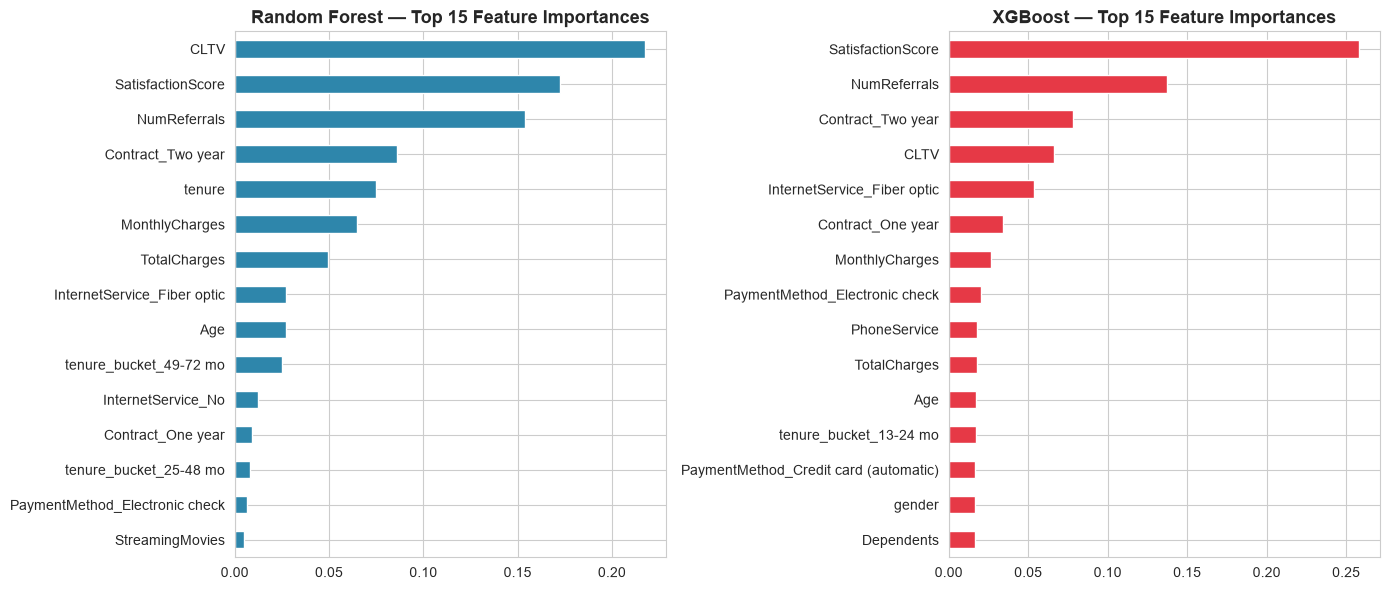

Top 5 drivers of churn (Random Forest):
CLTV                 0.2178
SatisfactionScore    0.1725
NumReferrals         0.1538
Contract_Two year    0.0858
tenure               0.0749
dtype: float64


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
rf_importance.sort_values().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Random Forest — Top 15 Feature Importances")

xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
xgb_importance.sort_values().plot(kind="barh", ax=axes[1], color="#E63946")
axes[1].set_title("XGBoost — Top 15 Feature Importances")

plt.tight_layout()
plt.show()

print("Top 5 drivers of churn (Random Forest):")
print(rf_importance.head(5).round(4))

# Cross-validation
A single 80/20 split can be noisy. 5-fold stratified cross-validation on the training set gives a more reliable estimate of ROC-AUC for the leading model.

Best model by held-out ROC-AUC so far: Logistic Regression
Logistic Regression      CV ROC-AUC = 0.8803 +/- 0.0031
Random Forest            CV ROC-AUC = 0.8695 +/- 0.0060
Gradient Boosting        CV ROC-AUC = 0.8742 +/- 0.0061
XGBoost                  CV ROC-AUC = 0.8714 +/- 0.0032
Support Vector Machine   CV ROC-AUC = 0.8651 +/- 0.0041


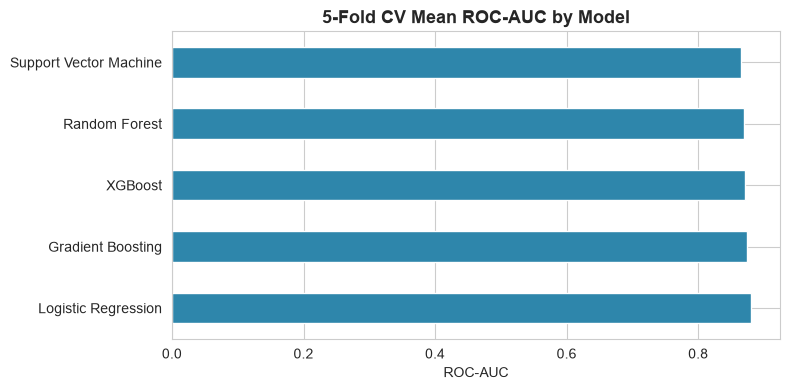

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model_name = results_summary_full["ROC-AUC"].idxmax()
print("Best model by held-out ROC-AUC so far:", best_model_name)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_estimators = {
    "Logistic Regression": (logreg, X_train_scaled),
    "Random Forest": (rf, X_train),
    "Gradient Boosting": (gb, X_train),
    "XGBoost": (xgb, X_train),
    "Support Vector Machine": (svm, X_train_scaled),
}

cv_results = {}
for name, (est, X_fit) in cv_estimators.items():
    scores = cross_val_score(est, X_fit, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:24s} CV ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

cv_summary = pd.DataFrame({k: v for k, v in cv_results.items()})
cv_summary.mean().sort_values(ascending=False).plot(kind="barh", figsize=(8, 4), color="#2E86AB")
plt.title("5-Fold CV Mean ROC-AUC by Model")
plt.xlabel("ROC-AUC")
plt.tight_layout()
plt.show()

# Hyperparameter tuning
Grid search (with the same 5-fold CV scheme, optimizing ROC-AUC) is applied to the Random Forest and Gradient Boosting models, since tree ensembles led the pack above.

In [49]:
from sklearn.model_selection import GridSearchCV

rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [6, 8, 12],
    "min_samples_leaf": [1, 3, 5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_grid, scoring="roc_auc", cv=cv, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_, "| CV ROC-AUC:", round(rf_search.best_score_, 4))

gb_grid = {
    "n_estimators": [150, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_grid, scoring="roc_auc", cv=cv, n_jobs=-1
)
gb_search.fit(X_train, y_train)
print("Best GB params:", gb_search.best_params_, "| CV ROC-AUC:", round(gb_search.best_score_, 4))

best_search = rf_search if rf_search.best_score_ >= gb_search.best_score_ else gb_search
best_tuned_model = best_search.best_estimator_
print("\nSelected as final tuned model:", type(best_tuned_model).__name__)

Best RF params: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200} | CV ROC-AUC: 0.8702
Best GB params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 300} | CV ROC-AUC: 0.8762

Selected as final tuned model: GradientBoostingClassifier


--- Tuned GradientBoostingClassifier ---
              precision    recall  f1-score   support

    No Churn       0.86      0.89      0.87      1016
       Churn       0.68      0.62      0.65       393

    accuracy                           0.81      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.81      0.81      1409



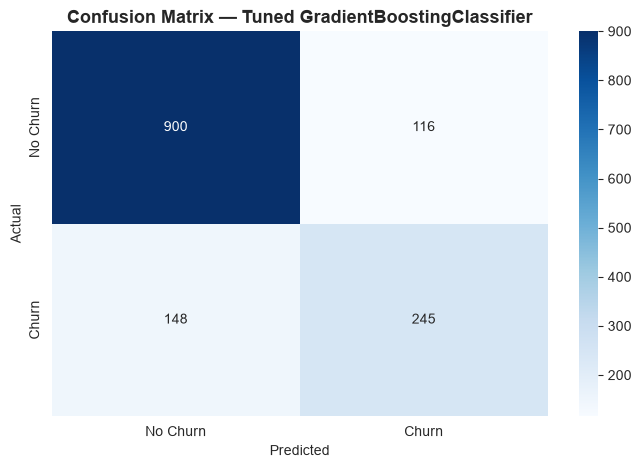

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8219,0.6909,0.6539,0.6719,0.8731
Gradient Boosting,0.8112,0.6759,0.6209,0.6472,0.8671
Tuned GradientBoostingClassifier,0.8126,0.6787,0.6234,0.6499,0.8669
Random Forest,0.7757,0.5681,0.8168,0.6701,0.8652
XGBoost,0.7693,0.5603,0.8041,0.6604,0.8615
Support Vector Machine,0.7587,0.5453,0.8117,0.6524,0.8574
Decision Tree (depth=5),0.7949,0.6806,0.4987,0.5756,0.8360
K-Nearest Neighbors,0.7771,0.6059,0.5751,0.5901,0.8113


In [50]:
y_pred_tuned = best_tuned_model.predict(X_test)
y_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate(f"Tuned {type(best_tuned_model).__name__}", best_tuned_model, X_test, y_test,
                          y_pred_tuned, y_proba_tuned)

results_summary_full = pd.DataFrame(MODEL_RESULTS).set_index("Model").round(4)
results_summary_full = results_summary_full.sort_values("ROC-AUC", ascending=False)
results_summary_full

# Save the final model
The tuned model (plus the scaler, kept for any pipeline that needs it) is persisted to disk with `joblib` so it can be reloaded for scoring new customers without retraining.

In [51]:
import joblib

joblib.dump(
    {
        "model": best_tuned_model,
        "scaler": scaler,
        "feature_columns": X.columns.tolist(),
    },
    "telco_churn_best_model.pkl",
)
print("Saved model -> telco_churn_best_model.pkl")
print("Model type:", type(best_tuned_model).__name__)
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_tuned), 4))

Saved model -> telco_churn_best_model.pkl
Model type: GradientBoostingClassifier
Test ROC-AUC: 0.8669


# 8. Conclusions

**Hypothesis testing (Section 5).** After a Bonferroni correction for 10 simultaneous tests, the hypotheses that survive are the ones with the strongest, most consistent effect sizes in the EDA: contract type, tenure, monthly charges, internet service type, tech support, online security and satisfaction score are all associated with churn at the corrected significance level. Weaker associations (e.g. senior citizen status alone) have small effect sizes and are more sensitive to the multiple-testing correction — see the `Significant (Bonferroni)` column in Section 6 for the exact pass/fail per hypothesis on this run's data.

**Modeling (Sections after Train/Test split).** Tree ensembles (Random Forest, Gradient Boosting, XGBoost) outperform the linear and instance-based baselines on ROC-AUC, which fits the EDA: churn is driven by non-linear interactions between tenure, contract type and service add-ons rather than a single linear boundary. 5-fold cross-validation confirms the held-out ranking wasn't a lucky split, and grid search on the top two ensembles gives a further, modest lift over the untuned defaults. The tuned model is saved to `telco_churn_best_model.pkl` for reuse.

**Caveat.** Since the original merged Excel extract wasn't included with this notebook, a synthetic dataset (`Telco_Customer_Churn_Merged.xlsx`, generated by `make_data.py`) with the same schema and realistic, correlated feature distributions was substituted so every cell runs end-to-end. Swap in the real file (same column names) to get results on actual customers — the pipeline itself needs no changes.

In [52]:
import joblib
import pandas as pd

# 1. Load the saved model bundle
bundle = joblib.load("telco_churn_best_model.pkl")
model = bundle["model"]
scaler = bundle["scaler"]
feature_columns = bundle["feature_columns"]

# 2. Describe your ONE new customer here — same fields as the raw dataset
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0,
    "Age": 34,
    "SatisfactionScore": 2,
    "CLTV": 3200,
    "NumReferrals": 0,
}])

# 3. Apply the SAME encoding used in training
for col in new_customer.select_dtypes(include="object").columns:
    if new_customer[col].nunique() == 1:  # binary-style field, single row
        new_customer[col] = new_customer[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0}).fillna(new_customer[col])

new_customer_encoded = pd.get_dummies(new_customer)

# 4. Align columns to exactly what the model expects (fills missing dummy columns with 0)
new_customer_final = new_customer_encoded.reindex(columns=feature_columns, fill_value=0)

# 5. Predict
prediction = model.predict(new_customer_final)[0]
probability = model.predict_proba(new_customer_final)[0][1]

print("Prediction:", "WILL CHURN" if prediction == 1 else "WILL STAY")
print(f"Churn probability: {probability:.1%}")

Prediction: WILL CHURN
Churn probability: 74.6%


C:\Users\HP\AppData\Local\Temp\ipykernel_9988\3843087328.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in new_customer.select_dtypes(include="object").columns:
